/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/4221379449.py:11: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/4221379449.py:12: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


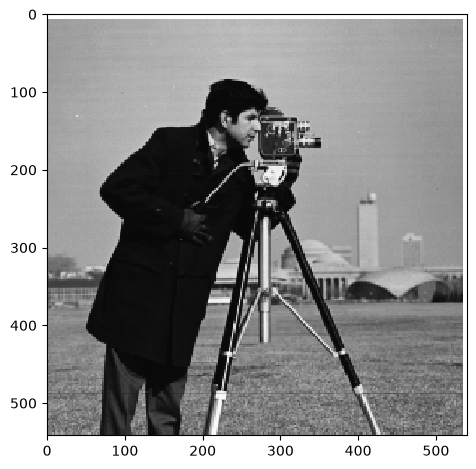

(542, 540)

In [1]:
import numpy as np
import skimage as sk
import skimage.io as skio

imname = 'images/cameraman.png'

im = skio.imread(imname)
im = sk.img_as_float(im)
im = sk.color.rgb2gray(im[:, :, :3])

skio.imshow(im)
skio.show()
im.shape

In [2]:
def convolution(img, kernel, padding=None):
    h, w = kernel.shape
    m, n = img.shape
    kernel = kernel[::-1,::-1]

    if padding == "same":
        # (m - h + 1) + 2 * pad = m -> 2 * pad = h - 1 -> odd kernel, pad = h // 2
        pad_h = h // 2
        pad_w = w // 2
    elif padding == "full":
        pad_h = h - 1
        pad_w = w - 1

    img_pad = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)))

    h_out = img_pad.shape[0] - h + 1
    w_out = img_pad.shape[1] - w + 1

    img_out = np.zeros(shape=(h_out, w_out))

    for i in range(h_out):
        for j in range(w_out):
            val = 0
            for k in range(h):
                for l in range(w):
                    val += kernel[k][l] * img_pad[i+k][j+l]
            img_out[i][j] = val

    return img_out


/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/467859501.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_blurred)
/Users/namwook_lee/.venvs/cs180/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/467859501.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


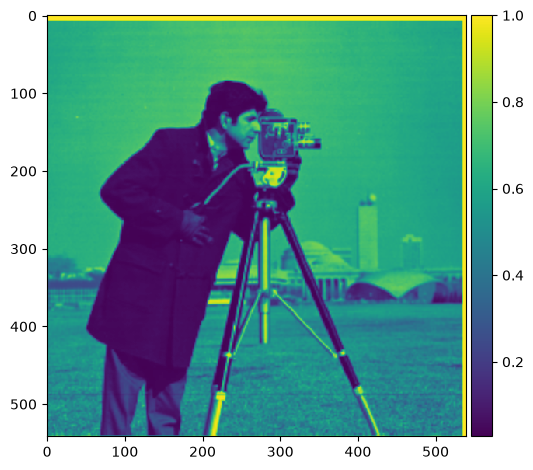

In [7]:
import cv2

gv = cv2.getGaussianKernel(3, 1)
gf = np.outer(gv, gv)

im_blurred = convolution(im, gf, "same")

skio.imshow(im_blurred)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/2379273352.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(imx)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/2379273352.py:7: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


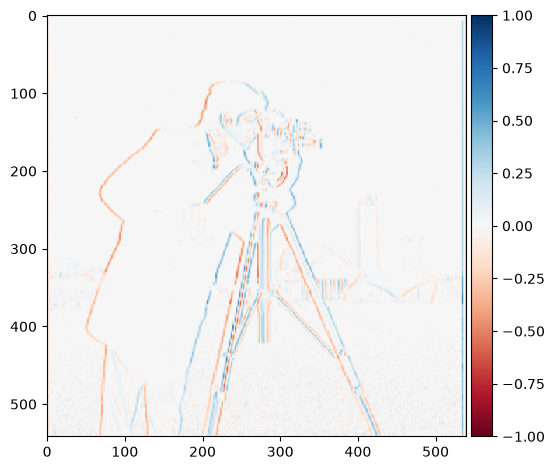

In [9]:
Dx = np.array([[1, 0, -1]])
Dy = np.array([[1], [0], [-1]])

imx = convolution(im_blurred, Dx, "same")

skio.imshow(imx)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/2812438964.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(imy)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/2812438964.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


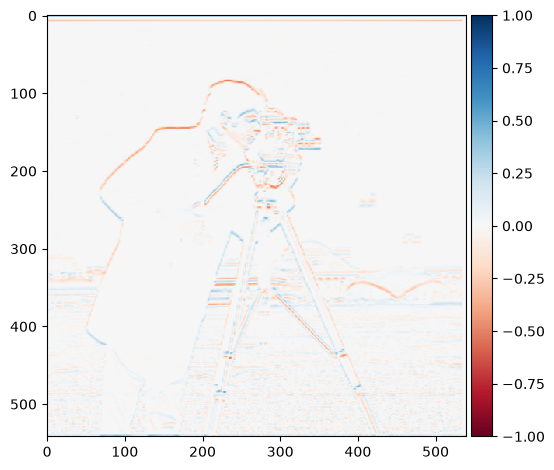

In [10]:
imy = convolution(im_blurred, Dy, "same")

skio.imshow(imy)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/1389870611.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(grad_mg)
/Users/namwook_lee/.venvs/cs180/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Float image out of standard range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/1389870611.py:4: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


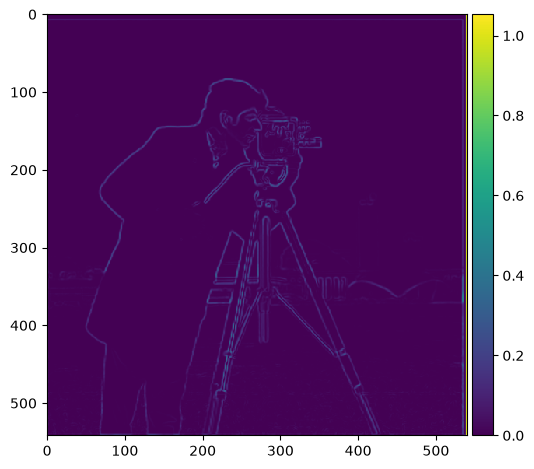

In [11]:
grad_mg = imx ** 2 + imy ** 2

skio.imshow(grad_mg)
skio.show()

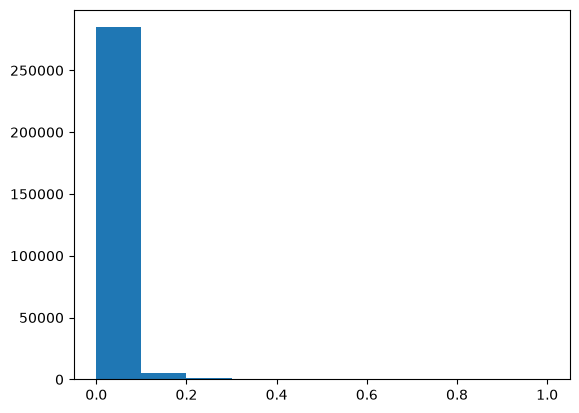

In [12]:
from matplotlib import pyplot as plt

plt.hist(grad_mg.flatten(), bins=10, range=(0, 1))
plt.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/2021419070.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_edge)
/Users/namwook_lee/.venvs/cs180/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/2021419070.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


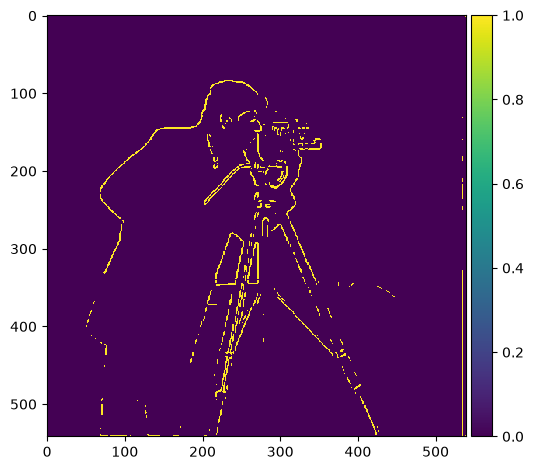

In [13]:
threshold = 0.1

im_edge = np.where(grad_mg > threshold, 1, 0)

skio.imshow(im_edge)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/3832955055.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_edge)
/Users/namwook_lee/.venvs/cs180/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/3832955055.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


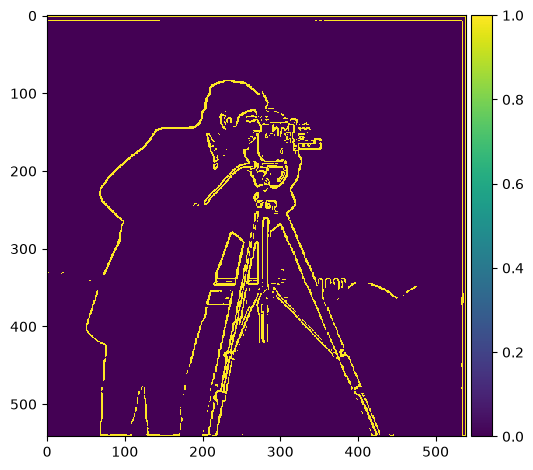

In [14]:
threshold = 0.05

im_edge = np.where(grad_mg > threshold, 1, 0)

skio.imshow(im_edge)
skio.show()

/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/593602484.py:5: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.imshow(im_edge)
/Users/namwook_lee/.venvs/cs180/lib/python3.11/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)
/var/folders/k1/fj7cl3m153q3m7z92s_nt1hw0000gn/T/ipykernel_42576/593602484.py:6: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  skio.show()


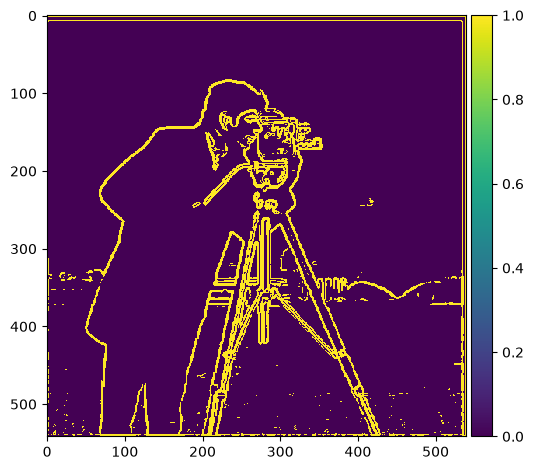

In [16]:
threshold = 0.02

im_edge = np.where(grad_mg > threshold, 1, 0)

skio.imshow(im_edge)
skio.show()

In [17]:
DoGx = convolution(gf, Dx, padding="full")
DoGy = convolution(gf, Dy, padding="full")

In [24]:
imdx = convolution(im, DoGx, "same")
imdy = convolution(im, DoGy, "same")

In [33]:
from matplotlib import pyplot as plt

im_DoG = imdx ** 2 + imdy ** 2

np.array_equal(grad_mg, im_DoG)


array([[4.98544551e-01, 4.73023630e-01, 4.73023630e-01, ...,
        4.73023630e-01, 4.73023630e-01, 4.98544551e-01],
       [4.73023630e-01, 1.66533454e-16, 8.32667268e-17, ...,
        8.32667268e-17, 1.66533454e-16, 4.73023630e-01],
       [4.73023630e-01, 8.32667268e-17, 3.85185989e-34, ...,
        3.85185989e-34, 8.32667268e-17, 4.73023630e-01],
       ...,
       [2.63925815e-01, 1.38777878e-17, 2.77555756e-17, ...,
        3.85185989e-34, 8.32667268e-17, 4.73023630e-01],
       [3.21232964e-01, 1.88041314e-19, 1.38777878e-17, ...,
        0.00000000e+00, 8.32667268e-17, 4.73023630e-01],
       [4.15342434e-01, 3.21232964e-01, 2.66064141e-01, ...,
        4.73023630e-01, 4.73023630e-01, 4.98544551e-01]], shape=(542, 540))

In [34]:
print(grad_mg.shape, im_DoG.shape, grad_mg.dtype, im_DoG.dtype)
d = np.abs(grad_mg - im_DoG)
print("max diff:", d.max(), " interior max:", d[5:-5, 5:-5].max())
print("allclose:", np.allclose(grad_mg, im_DoG))

(542, 540) (542, 540) float64 float64
max diff: 0.4985445509414048  interior max: 3.885780586188048e-16
allclose: False
